# Experiment 3: sampling and accumulation during training

Ninety-six trials compare one sampled batch per table visit, a reshuffled disjoint full pass with an update per chunk, and the same chunks with one averaged-gradient update per table. All arms use LR 3e-7, L2-SP 0.003, full parameter updates and seed 42. PD sampling preserves class proportions in every arm; the balanced-PD experiment-1 reference is not its one-sample control.

## 0. Evidence and scope

DATA manifests describe progress. Detailed trajectories and benchmark predictions come from project storage. Missing evidence is unavailable, never a zero effect.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize import comparisons as cmp, pilots as pv, optimization as op
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
style.apply()
sink = FigureSaver('experiment3/01_training')
report = cp.NotebookReport('Experiment 3: sampling and accumulation during training', sink=sink)
print(source_description())
report.add('0. Evidence and scope', source_description())

DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Protocol coverage

All protocols retain the same four dataset partitions, row caps, update budget and schedule.

,evidence,records,origin
0,Planned trials,48,Config; not scheduler state
1,Completed trials,7,DATA manifests
2,Epoch rows,4142,Project training diagnostics
3,Milestone rows,67,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


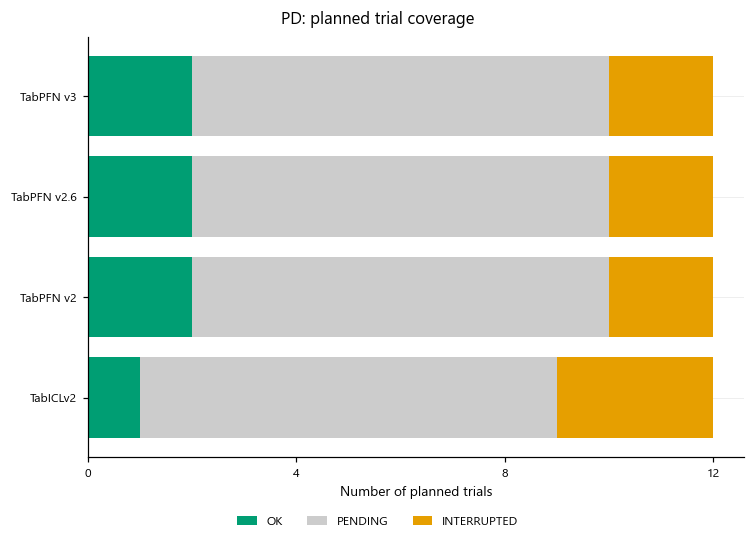

PD. Recorded status of 48 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

,evidence,records,origin
0,Planned trials,48,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,6602,Project training diagnostics
3,Milestone rows,48,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


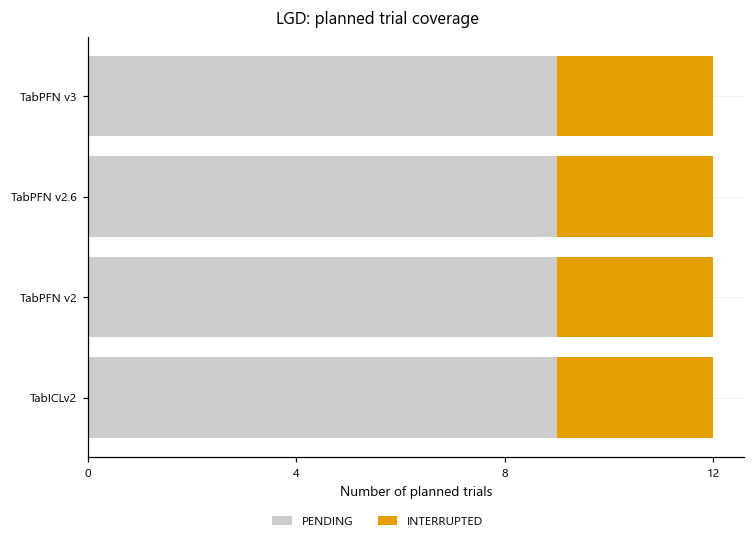

LGD. Recorded status of 48 planned LGD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

In [2]:
runs = [cp.load_campaign(3, track) for track in ('pd', 'lgd')]
for run in runs:
    report.table(run.track.upper()+' evidence', pub.availability(run))
    cp.show(sink, cp.plot_coverage(run), track=run.track)
report.add('1. Protocol coverage', 'There are 48 trials per task. A saved interruption is recoverable progress, not a completed checkpoint or numerical failure.')

## 2. Loss and optimization dynamics

Follow the native loss, gradient norms, clipping and parameter movement. Objective values reflect the sampled batches and should not be compared as identical full-corpus objectives.

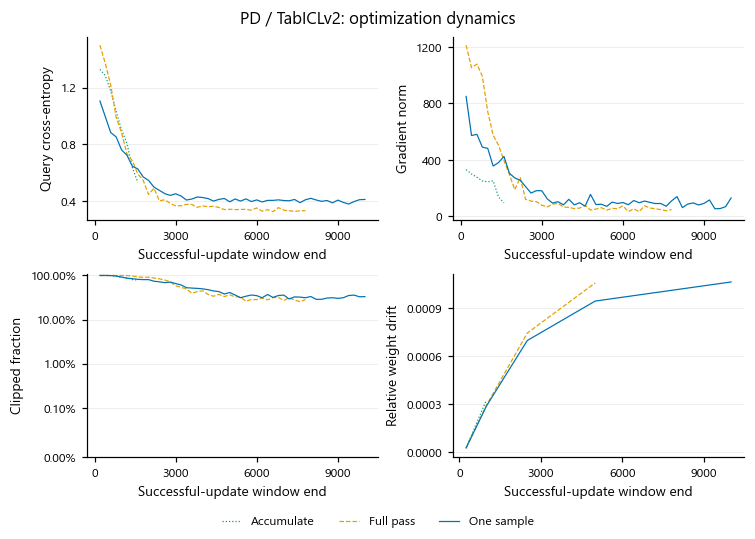

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

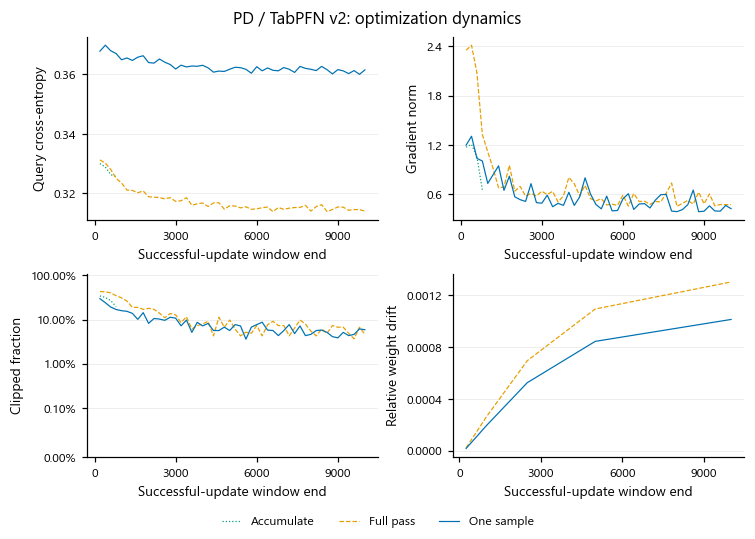

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

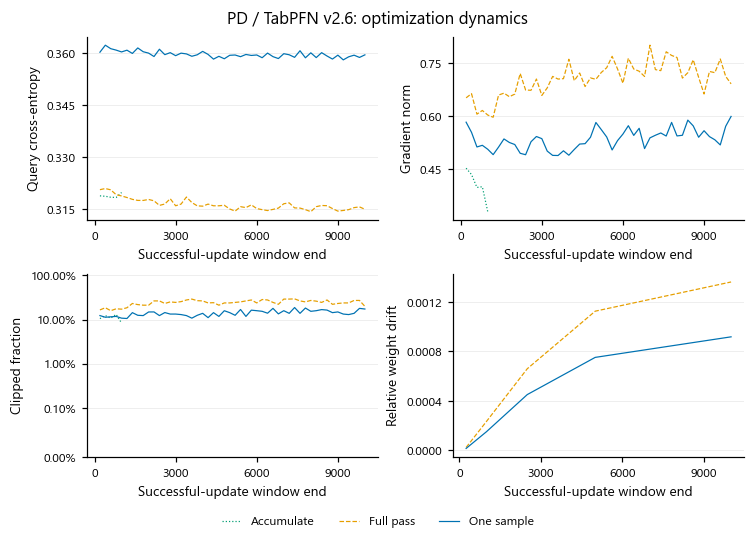

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

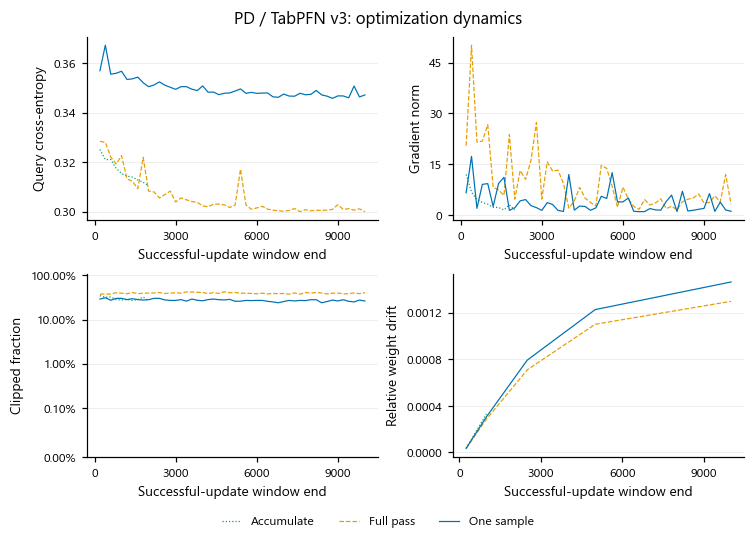

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,seed,epochs,nonfinite_diagnostics,peak_epoch_gradient,peak_epoch_clipped_fraction,peak_l2sp_penalty,amp_skips,data_skips,peak_weight_drift
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,42,770,0,5.835126,0.461538,7.920760e-05,0,0,0.001013
1,TabPFN v2,3.000000e-07,0.003,False,full_pass,0,42,61,0,2.413474,0.432927,1.308352e-04,0,0,0.001302
2,TabPFN v2,3.000000e-07,0.003,False,accumulate,0,42,55,0,1.466699,0.384615,1.704230e-06,0,0,0.000021
3,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,42,770,0,1.094158,0.384615,8.852005e-05,0,0,0.000917
4,TabPFN v2.6,3.000000e-07,0.003,False,full_pass,0,42,67,0,0.804304,0.304636,1.948771e-04,0,0,0.001361
5,TabPFN v2.6,3.000000e-07,0.003,False,accumulate,0,42,73,0,0.565246,0.230769,2.954368e-06,0,0,0.000019
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,42,770,0,162.728204,0.461538,1.786039e-04,0,0,0.001464
7,TabPFN v3,3.000000e-07,0.003,False,full_pass,0,42,145,0,70.663949,0.463768,1.402967e-04,0,0,0.001297
8,TabPFN v3,3.000000e-07,0.003,False,accumulate,0,42,142,0,53.385336,0.538462,3.377858e-05,0,0,0.000323
9,TabICLv2,3.000000e-07,0.003,False,one_sample,0,42,770,0,1634.852242,1.000000,5.031017e-04,0,0,0.001064


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,recorded_epochs,full_coverage_epochs,fullest_observed_tables,min_observed_tables,last_update,partial_coverage_epochs
0,cpt_sampling_v5_s00_pd_tabicl-classifier-v2-20...,TabICLv2,3.000000e-07,0.003,False,accumulate,121,121,13,13,1573,0
1,cpt_sampling_v5_s00_pd_tabicl-classifier-v2-20...,TabICLv2,3.000000e-07,0.003,False,full_pass,112,112,13,13,7728,0
2,cpt_sampling_v5_s00_pd_tabicl-classifier-v2-20...,TabICLv2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
3,cpt_sampling_v5_s00_pd_tabpfn-v2-classifier-v2...,TabPFN v2,3.000000e-07,0.003,False,accumulate,55,55,13,13,715,0
4,cpt_sampling_v5_s00_pd_tabpfn-v2-classifier-v2...,TabPFN v2,3.000000e-07,0.003,False,full_pass,61,61,13,13,10000,0
5,cpt_sampling_v5_s00_pd_tabpfn-v2-classifier-v2...,TabPFN v2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
6,cpt_sampling_v5_s00_pd_tabpfn-v2.6-classifier-...,TabPFN v2.6,3.000000e-07,0.003,False,accumulate,73,73,13,13,949,0
7,cpt_sampling_v5_s00_pd_tabpfn-v2.6-classifier-...,TabPFN v2.6,3.000000e-07,0.003,False,full_pass,67,66,13,9,10000,1
8,cpt_sampling_v5_s00_pd_tabpfn-v2.6-classifier-...,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
9,cpt_sampling_v5_s00_pd_tabpfn-v3-classifier-v3...,TabPFN v3,3.000000e-07,0.003,False,accumulate,142,142,13,13,1846,0


,trial_name,successful_updates,train_loss,observed_tables,full_observed_tables,complete_pass,base,learning_rate,l2sp_lambda,frozen,sampling
0,cpt_sampling_v5_s00_pd_tabicl-classifier-v2-20...,10000,0.856034,3,13,False,TabICLv2,3.000000e-07,0.003,False,one_sample
1,cpt_sampling_v5_s00_pd_tabpfn-v2-classifier-v2...,10000,0.342411,3,13,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
2,cpt_sampling_v5_s00_pd_tabpfn-v2.6-classifier-...,10000,0.290937,9,13,False,TabPFN v2.6,3.000000e-07,0.003,False,full_pass
3,cpt_sampling_v5_s00_pd_tabpfn-v2.6-classifier-...,10000,0.339827,3,13,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
4,cpt_sampling_v5_s00_pd_tabpfn-v3-classifier-v3...,10000,0.330655,3,13,False,TabPFN v3,3.000000e-07,0.003,False,one_sample


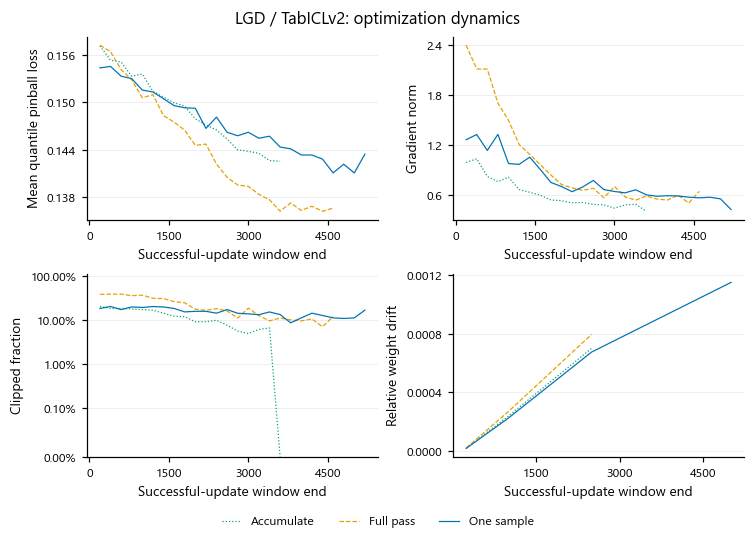

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

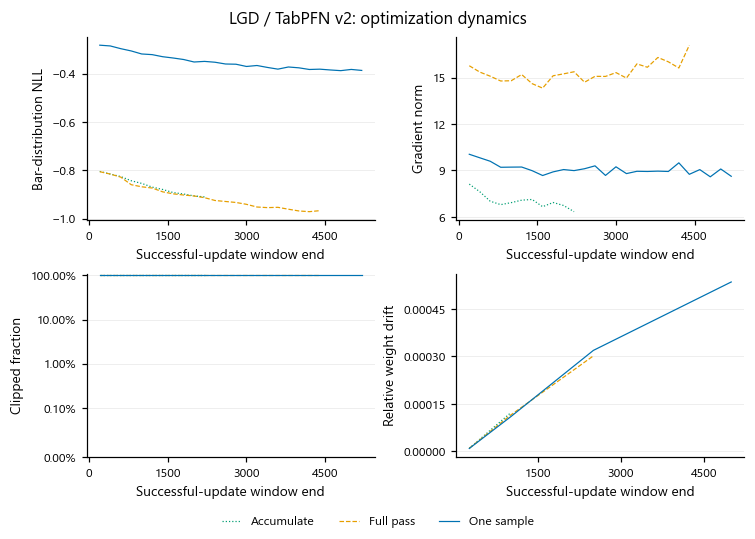

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

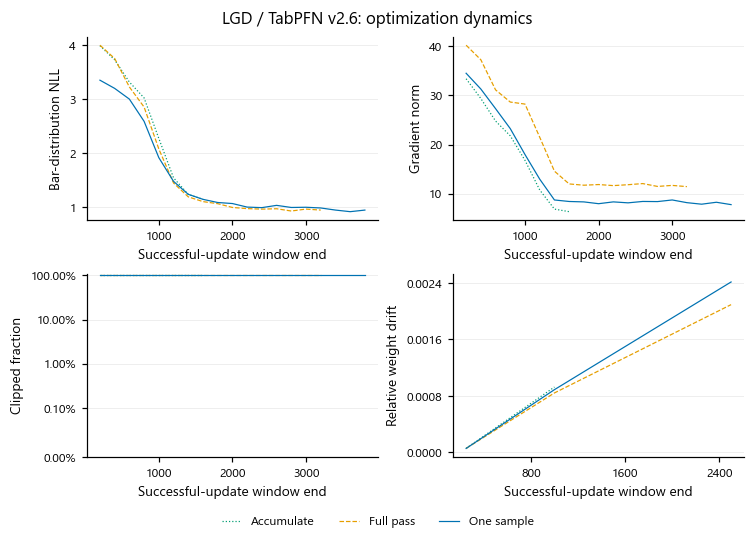

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

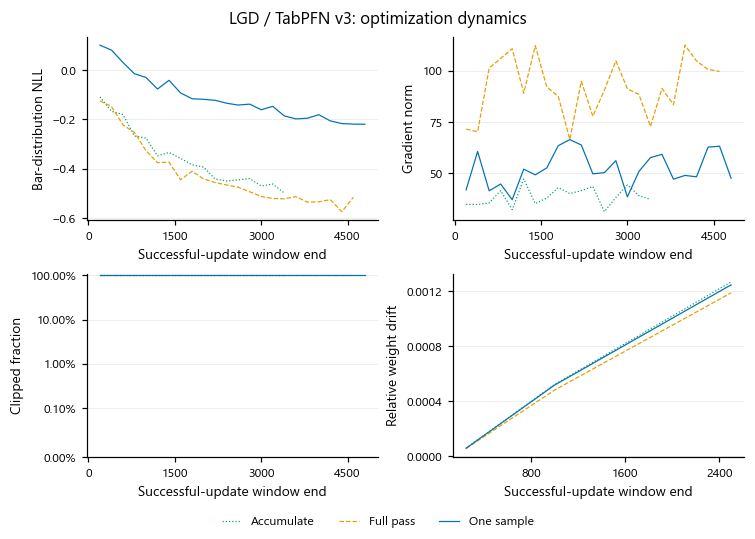

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,seed,epochs,nonfinite_diagnostics,peak_epoch_gradient,peak_epoch_clipped_fraction,peak_l2sp_penalty,amp_skips,data_skips,peak_weight_drift
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,42,857,0,19.884060,1.0,0.000165,0,0,0.000535
1,TabPFN v2,3.000000e-07,0.003,False,full_pass,0,42,358,0,22.181195,1.0,0.000118,0,0,0.000302
2,TabPFN v2,3.000000e-07,0.003,False,accumulate,0,42,361,0,16.910326,1.0,0.000050,0,0,0.000122
3,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,42,614,0,39.101089,1.0,0.000933,0,0,0.002416
4,TabPFN v2.6,3.000000e-07,0.003,False,full_pass,0,42,265,0,46.024405,1.0,0.000613,0,0,0.002094
5,TabPFN v2.6,3.000000e-07,0.003,False,accumulate,0,42,263,0,37.260827,1.0,0.000319,0,0,0.000924
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,42,775,0,384.977130,1.0,0.000566,0,0,0.001248
7,TabPFN v3,3.000000e-07,0.003,False,full_pass,0,42,561,0,376.462394,1.0,0.000483,0,0,0.001189
8,TabPFN v3,3.000000e-07,0.003,False,accumulate,0,42,563,0,207.896868,1.0,0.000390,0,0,0.001269
9,TabICLv2,3.000000e-07,0.003,False,one_sample,0,42,834,0,3.466794,0.5,0.000391,0,0,0.001150


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,recorded_epochs,full_coverage_epochs,fullest_observed_tables,min_observed_tables,last_update,partial_coverage_epochs
0,cpt_sampling_v5_s00_lgd_tabicl-regressor-v2-20...,TabICLv2,3.000000e-07,0.003,False,accumulate,568,568,6,6,3408,0
1,cpt_sampling_v5_s00_lgd_tabicl-regressor-v2-20...,TabICLv2,3.000000e-07,0.003,False,full_pass,571,571,6,6,4568,0
2,cpt_sampling_v5_s00_lgd_tabicl-regressor-v2-20...,TabICLv2,3.000000e-07,0.003,False,one_sample,834,834,6,6,5004,0
3,cpt_sampling_v5_s00_lgd_tabpfn-v2-regressor-v2...,TabPFN v2,3.000000e-07,0.003,False,accumulate,361,361,6,6,2166,0
4,cpt_sampling_v5_s00_lgd_tabpfn-v2-regressor-v2...,TabPFN v2,3.000000e-07,0.003,False,full_pass,358,358,6,6,4296,0
5,cpt_sampling_v5_s00_lgd_tabpfn-v2-regressor-v2...,TabPFN v2,3.000000e-07,0.003,False,one_sample,857,857,6,6,5142,0
6,cpt_sampling_v5_s00_lgd_tabpfn-v2.6-regressor-...,TabPFN v2.6,3.000000e-07,0.003,False,accumulate,263,263,6,6,1578,0
7,cpt_sampling_v5_s00_lgd_tabpfn-v2.6-regressor-...,TabPFN v2.6,3.000000e-07,0.003,False,full_pass,265,265,6,6,3180,0
8,cpt_sampling_v5_s00_lgd_tabpfn-v2.6-regressor-...,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,614,614,6,6,3684,0
9,cpt_sampling_v5_s00_lgd_tabpfn-v3-regressor-v3...,TabPFN v3,3.000000e-07,0.003,False,accumulate,563,563,6,6,3378,0


,trial_name,successful_updates,train_loss,observed_tables,full_observed_tables,complete_pass,base,learning_rate,l2sp_lambda,frozen,sampling


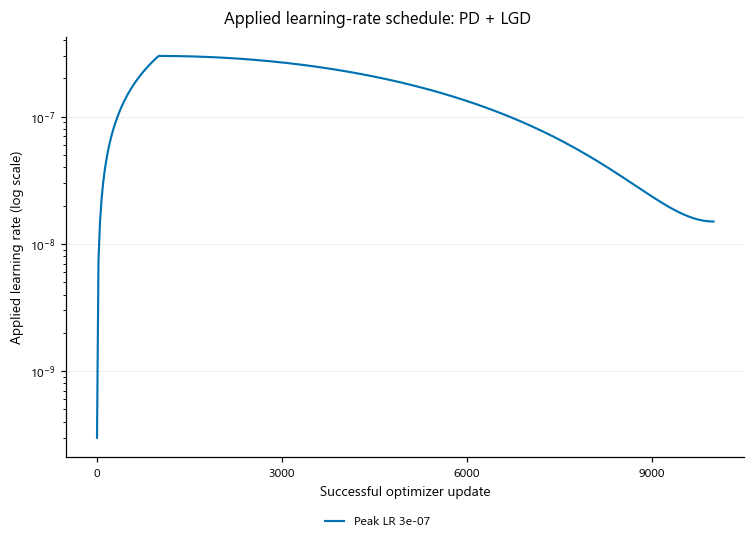

Learning rates evaluated from the recorded campaign configuration using the training scheduler. Each distinct peak-rate schedule is drawn once, pooling tasks only when budget, warmup and decay floor agree. The rate for update u is the scheduler value before that update (index u minus one). The first update has zero learning rate and is omitted from the logarithmic axis, but retained in the table. These are configured schedules; measured epoch-end rates and their sampling intervals are reported separately.

In [3]:
for run in runs:
    cp.show(sink, pv.plot_process_overview(run), track=run.track)
    report.table(run.track.upper()+' numerical health', pv.health_table(run))
    for label, frame in cp.loss_coverage_tables(run).items():
        report.table(run.track.upper()+' '+label, frame)
cp.show(sink, pv.plot_schedule(runs))
report.add('2. Loss and optimization dynamics', 'Data loss excludes L2-SP. Curves retain their recorded support; the shared schedule is shown once. The update budget is 10,000 successfully applied optimizer steps.')

## 3. Credit and non-credit trajectories at equal updates

Place the two domains side by side for each base. The mean requires every planned trial and unchanged baseline dataset coverage.

In [4]:
for run in runs:
    cp.show(sink, cmp.plot_sampling_curves(run), track=run.track)
report.add('3. Credit and non-credit trajectories at equal updates', 'One-sample, per-chunk full-pass and per-table accumulation do different amounts of work per update. Missing milestones remain gaps, and empty panels are omitted.')

No measurements available for this section yet.


No measurements available for this section yet.


## 4. Row exposure and matched cost

Repeat the trajectories against cumulative row exposure, then compare costs within the same completed partitions.

In [5]:
for run in runs:
    cp.show(sink, cmp.plot_sampling_curves(run, row_exposure=True), track=run.track)
    cp.show(sink, cmp.plot_sampling_costs(run), track=run.track)
report.add('4. Row exposure and matched cost', 'Exposure counts repeated rows. No interpolation claims equal row or compute budgets. Cost comparisons require all three protocols for a partition; absolute costs accompany their ratios.')

No measurements available for this section yet.
No measurements available for this section yet.


No measurements available for this section yet.
No measurements available for this section yet.


## 5. Resource utilization and parameter movement

Keep resource and tensor diagnostics separate from predictive endpoint results.

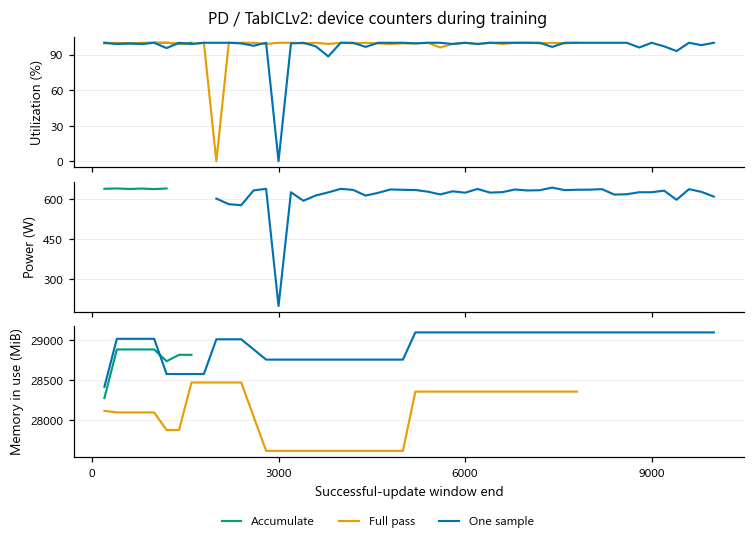

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

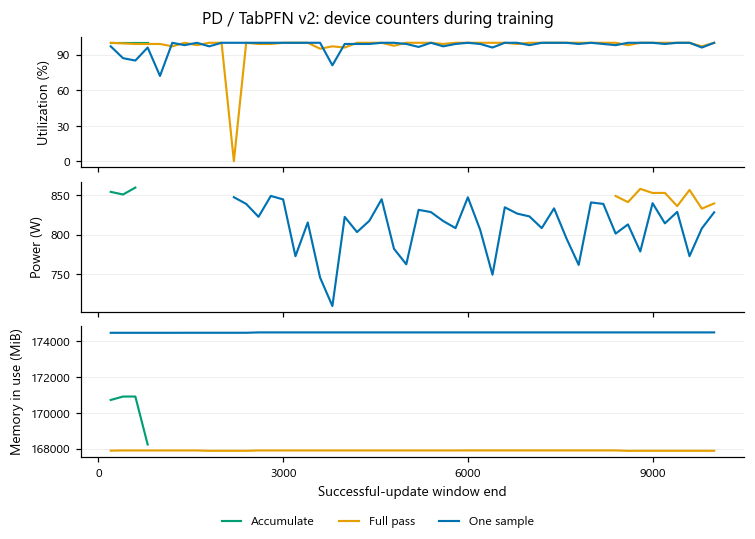

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

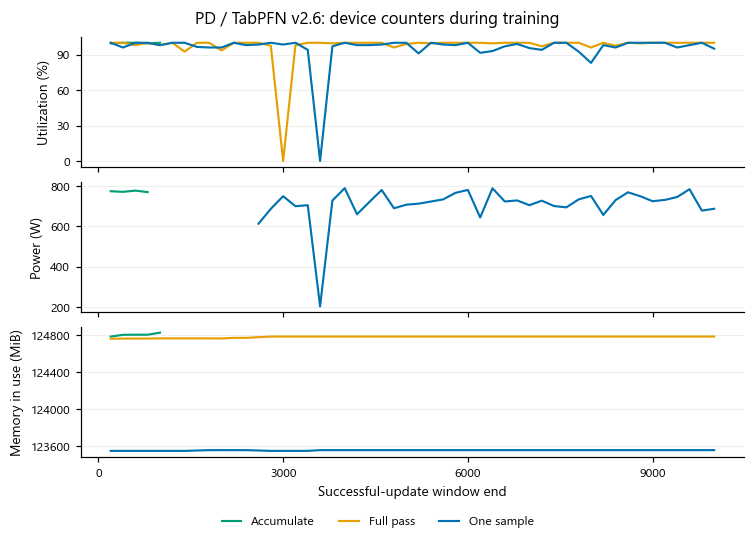

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

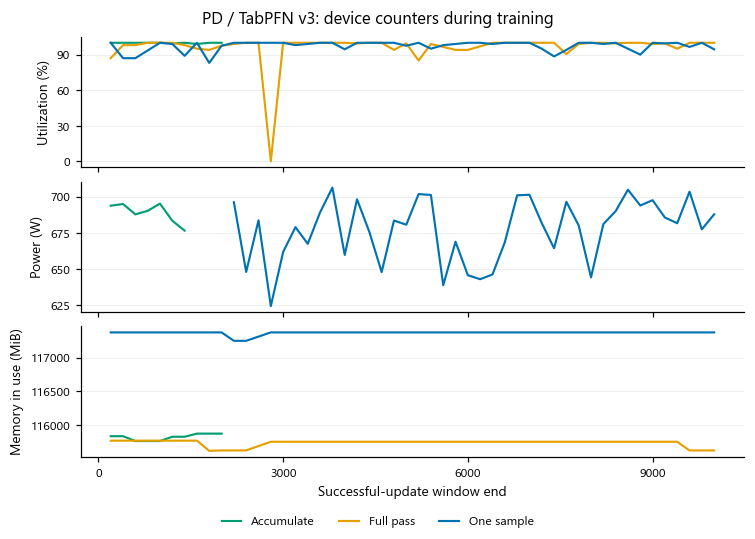

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

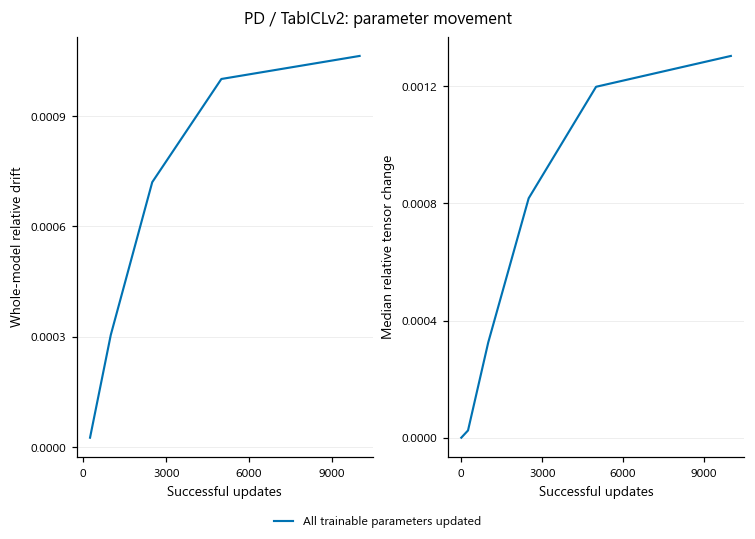

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

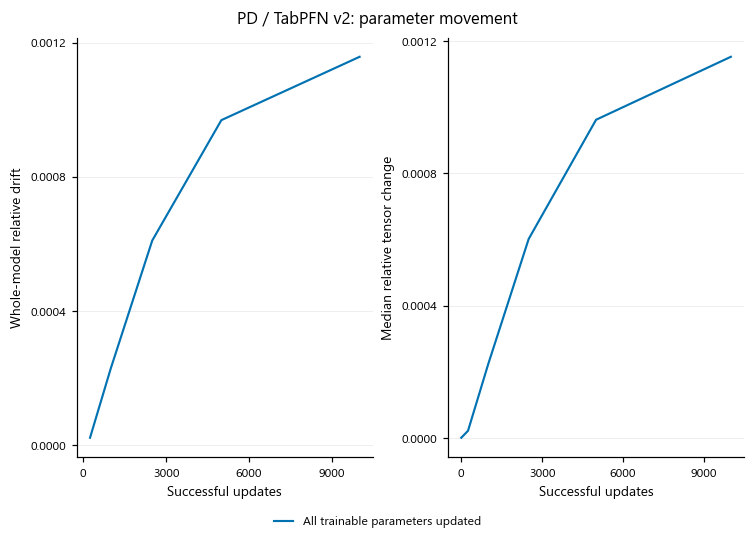

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

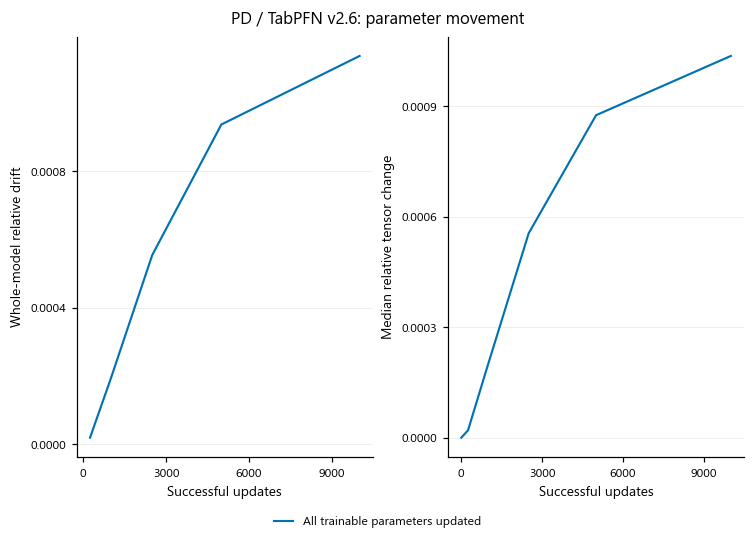

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

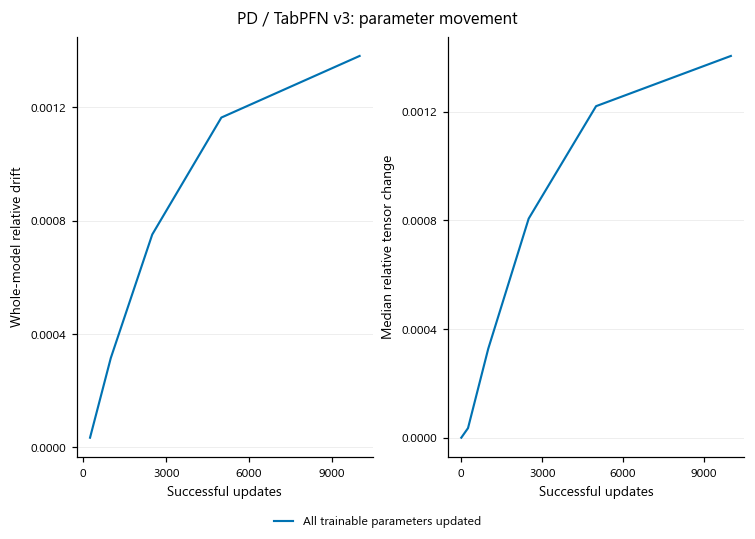

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

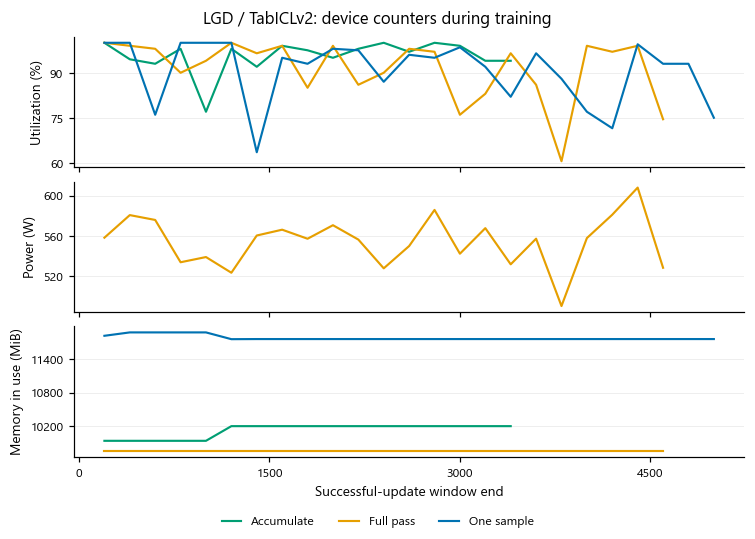

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

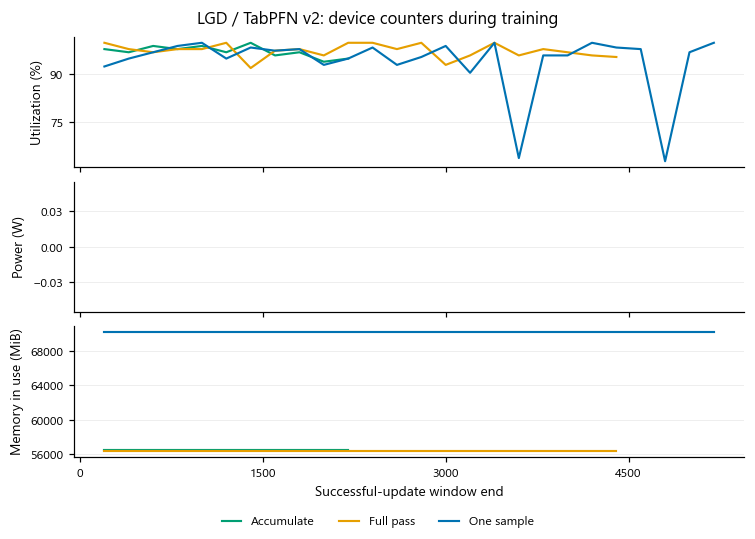

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

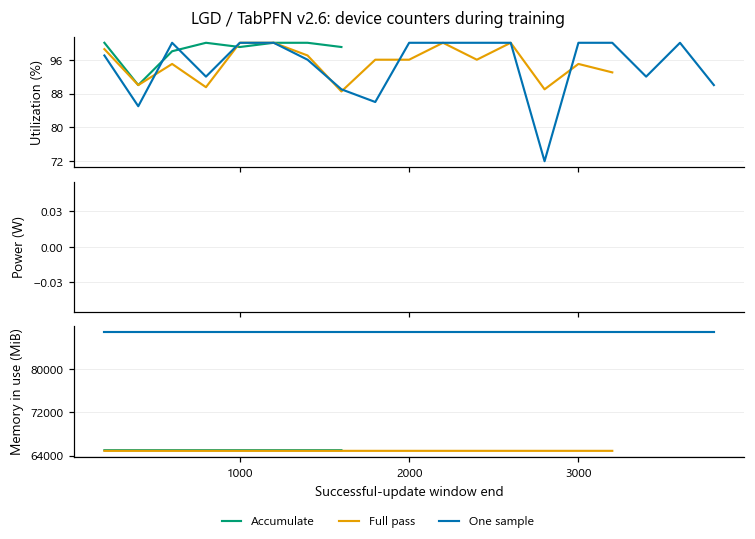

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

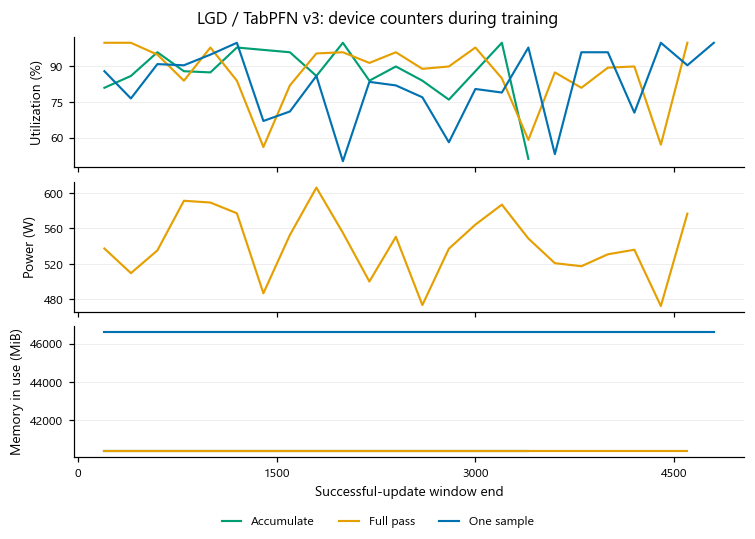

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

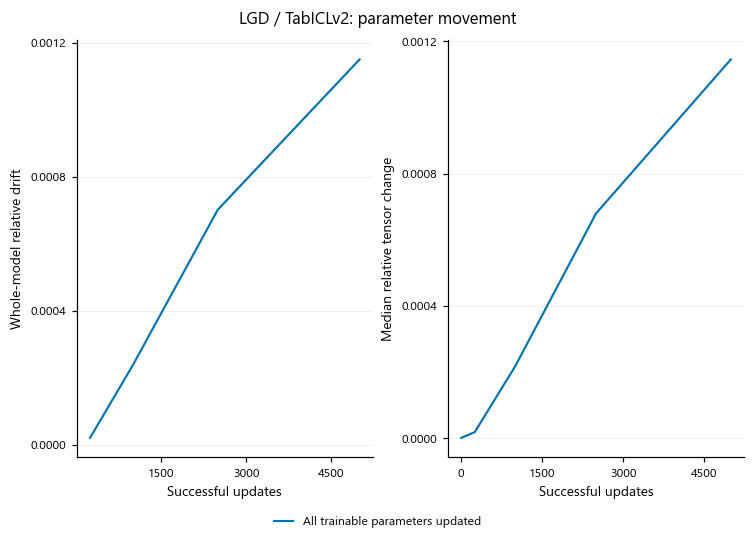

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

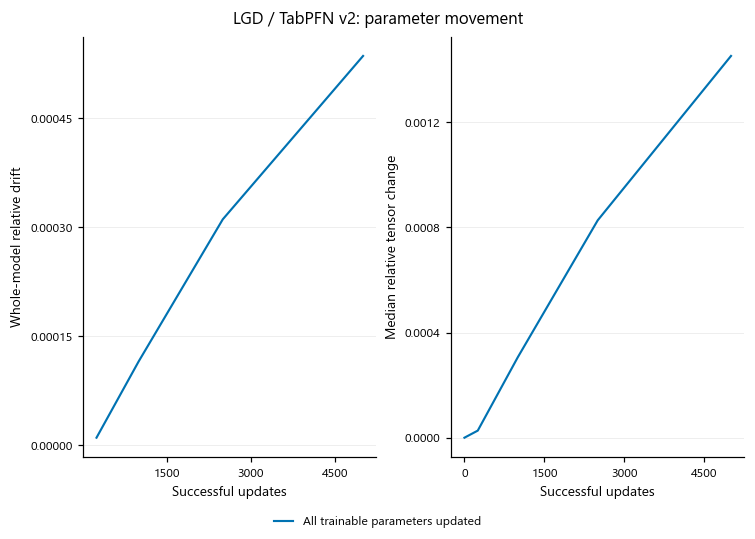

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

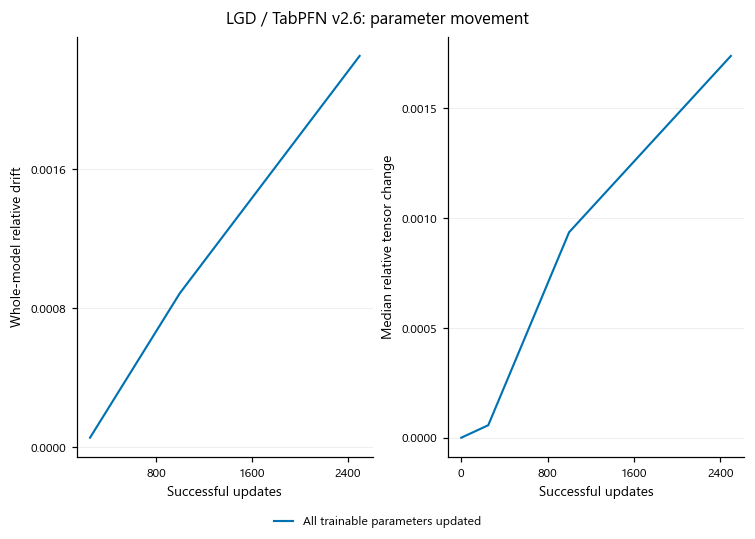

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

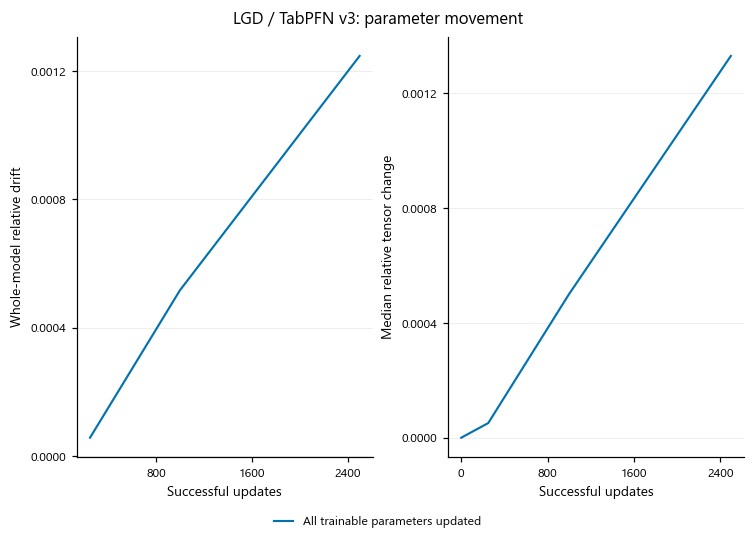

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

In [6]:
for run in runs:
    cp.show(sink, dg.plot_resource_curves(run), track=run.track)
    cp.show(sink, op.plot_movement(run), track=run.track)
report.add('5. Resource utilization and parameter movement', 'Recorded GPU/process counters and anchored displacement describe the execution. They do not establish energy consumption or causal effects of parameter movement.')

## Complete text summary

All displayed numerical values and captions, in section order.

In [7]:
print(report.summary(sink))

Experiment 3: sampling and accumulation during training

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Protocol coverage
There are 48 trials per task. A saved interruption is recoverable progress, not a completed checkpoint or numerical failure.

Table: PD evidence
           evidence  records                          origin
0    Planned trials       48     Config; not scheduler state
1  Completed trials        7                  DATA manifests
2        Epoch rows     4142    Project training diagnostics
3    Milestone rows       67  Project trajectory diagnostics
4   Benchmark folds        0        Project final evaluation

Figure: pd_coverage_pd
PD. Recorded status of 48 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure